# 🎵 Clasificación de Géneros Musicales — v7
## Correcciones basadas en outputs reales del v6

### Los 4 problemas del v6 y sus fixes

| Problema | Evidencia | Fix v7 |
|---|---|---|
| **Solo 10 epochs corrieron** | OneCycleLR para 37 epochs, early stopping en 10 | `duration 20→10s` → epoch 8min, caben 25+ epochs |
| **Clase 11 desbordada** | real=178, pred=476 en val; pred=1108 en test (17.8%!) | Eliminar boost×1.5 clase 11; focal_gamma 2.0→1.5 |
| **Encoder LR muy pequeño** | LR arranca en 2e-6 tras descongelar → converge lento | encoder lr 5e-6→2e-5; div_factor 25→10 |
| **Batch=16, 1106 batches/epoch** | ~35 min/epoch en T4 | `duration 10s` → 431 frames → batch 32, ~553 batches, ~8min/epoch |

### Cambio principal: audio de 20s → 10s
Los géneros musicales se identifican perfectamente en 10 segundos.
Reducir a la mitad los frames (863→431) baja los patches de 1020→495,
la atención cuadrática de 1M→245K pares por capa: **~4× más rápido**.


## 1. Instalación y configuración

In [3]:
!pip install -q librosa audiomentations timm transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 11.1 MB/s eta 0:00:00


In [4]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from collections import Counter

# Audio
import librosa
import soundfile as sf
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import GradScaler, autocast

# Transformers (AST)
from transformers import ASTModel, ASTConfig

# Métricas
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')

# =================================================================
# CONFIGURACIÓN GLOBAL — v6 con AST
# =================================================================
CFG = {
    # Paths
    'path': '/kaggle/input/datasets/jeffreyamc/music-genres-lab/',

    # Audio — igual que v5
    'sample_rate': 22050,
    'duration': 10,         # 20→10s: géneros identificables en 10s, 4× más rápido
    'n_mels': 128,
    'n_fft': 2048,
    'hop_length': 512,
    'fmin': 20,
    'fmax': 8000,

    # Normalización AudioSet: media y std con los que fue pre-entrenado el AST
    # Usar estos valores es crítico para que el transfer learning funcione bien
    'ast_mean': -4.2677393,
    'ast_std':   4.5689974,

    # Caché
    'cache_dir': '/kaggle/working/mel_cache_10s',  # Nueva caché para 10s

    # Modelo AST
    'ast_model': 'MIT/ast-finetuned-audioset-10-10-0.4593',
    'n_classes': 15,
    'dropout': 0.3,

    # Entrenamiento
    'epochs': 30,            # Con 10s/epoch de 8min caben 30 epochs en Kaggle
    'freeze_epochs': 2,       # 3→2: el head del AST converge en 2 epochs
    'batch_size': 32,         # Con 10s de audio caben 32 en T4
    'lr': 1e-3,              # Aumentado: el encoder necesita LR más alto para converger
    'weight_decay': 5e-3,     # Reducido: 1e-2 era demasiado restrictivo
    'label_smoothing': 0.1,
    'focal_gamma': 1.5,      # 2.0→1.5: gamma=2 causaba sobrepredicción de clases difíciles
    'mixup_alpha': 0.4,
    'use_mixup': True,

    # SpecAugment — moderado
    'freq_mask_param': 16,
    'time_mask_param': 48,
    'num_freq_masks': 2,
    'num_time_masks': 1,

    # K-Fold
    'n_folds': 5,
    'fold': 0,

    # Hardware
    'seed': 42,
    'num_workers': 2,         # 4→2: en T4 kaggle, 2 workers es óptimo
    'pin_memory': True,
    'fp16': True,
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(CFG['seed'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Carga y exploración de datos

In [12]:
path = CFG['path']
print(f'Contenido del directorio: {os.listdir(path)}')

# Cargar CSV de labels
train_df = pd.read_csv(os.path.join(path, 'train.csv'))
print(f'\nTrain: {len(train_df)} muestras')

# Rutas de audio
train_audio_path = os.path.join(path, 'train/train')
test_audio_path = os.path.join(path, 'test/test')

train_df['filepath'] = train_df['Id'].apply(lambda x: os.path.join(train_audio_path, f'{x}.wav'))

# Test: construir desde los archivos en disco
test_files = sorted([f.replace('.wav', '') for f in os.listdir(test_audio_path) if f.endswith('.wav')])
test_df = pd.DataFrame({'Id': test_files})
test_df['filepath'] = test_df['Id'].apply(lambda x: os.path.join(test_audio_path, f'{x}.wav'))
print(f'Test:  {len(test_df)} muestras')

# Verificar existencia
train_exists = train_df['filepath'].apply(os.path.exists).sum()
test_exists = test_df['filepath'].apply(os.path.exists).sum()
print(f'\nTrain existentes: {train_exists}/{len(train_df)}')
print(f'Test existentes:  {test_exists}/{len(test_df)}')

# Distribución de clases
print('\n--- Distribución de clases ---')
class_dist = train_df['Target'].value_counts().sort_index()
for cls, count in class_dist.items():
    bar = '█' * int(count / 200)
    print(f'  Clase {cls:2d}: {count:5d} {bar}')

print(f'\nRatio max/min: {class_dist.max()}/{class_dist.min()} = {class_dist.max()/class_dist.min():.0f}x')

Contenido del directorio: ['train.csv', 'test', 'train']

Train: 18719 muestras
Test:  6240 muestras


KeyboardInterrupt: 

## 3. Preprocesamiento de audio y augmentation

### Decisiones clave:
- **Mel-Spectrograma**: representación 2D tiempo×frecuencia. Estándar en audio DL.
- **Caché en disco (.npy)**: pre-calculamos TODOS los espectrogramas una sola vez (~5-8 min).
  Después, cada epoch carga `.npy` en vez de recalcular con librosa (~10-20x más rápido).
- **SpecAugment se aplica SOBRE el espectrograma cacheado**: así cada epoch ve datos diferentes
  sin el costo de recargar el audio. Esta es la corrección clave vs el notebook anterior.
- **Audio augmentation en el pre-cómputo**: para las clases minoritarias (<300 muestras),
  generamos N copias augmentadas durante el cacheo para ampliar esas clases.

In [15]:
# =================================================================
# AUDIO AUGMENTATION (para pre-cómputo de clases minoritarias)
# =================================================================

audio_augmentations = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.3),
    TimeStretch(min_rate=0.85, max_rate=1.15, p=0.3),
    PitchShift(min_semitones=-2, max_semitones=2, p=0.3),
    Shift(min_shift=-0.1, max_shift=0.1, p=0.2),
])


def load_audio(filepath, sr=22050, duration=20):
    """Carga audio con padding/truncado a longitud fija."""
    try:
        y, _ = librosa.load(filepath, sr=sr, duration=duration, mono=True)
    except Exception:
        y = np.zeros(sr * duration, dtype=np.float32)
    
    target_len = sr * duration
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode='reflect')
    else:
        y = y[:target_len]
    
    return y.astype(np.float32)


def audio_to_melspec(y, cfg):
    """
    Audio → Mel-Spectrograma normalizado (z-score) con tamaño fijo.
    
    Decisión: forzamos un número fijo de frames temporales (target_frames)
    para que todos los tensores tengan el mismo shape y PyTorch pueda
    hacer batch (torch.stack). Sin esto, audios de diferente duración
    o con TimeStretch producen espectrogramas de tamaño variable → crash.
    
    target_frames = ceil(duration * sr / hop_length) = ceil(20*22050/512) = 862
    """
    mel = librosa.feature.melspectrogram(
        y=y, sr=cfg['sample_rate'],
        n_mels=cfg['n_mels'], n_fft=cfg['n_fft'],
        hop_length=cfg['hop_length'],
        fmin=cfg['fmin'], fmax=cfg['fmax']
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # Normalización AudioSet: media=-4.27, std=4.57
    # CRÍTICO: usar las mismas estadísticas con las que el AST fue pre-entrenado.
    # Si normalizamos diferente, los activations del AST no corresponden a lo esperado.
    mel_db = (mel_db - cfg['ast_mean']) / (cfg['ast_std'] + 1e-8)
    
    # Fijar número de frames temporales
    target_frames = int(np.ceil(cfg['duration'] * cfg['sample_rate'] / cfg['hop_length'])) + 1  # 862
    n_frames = mel_db.shape[1]
    
    if n_frames < target_frames:
        # Pad con ceros (silencio normalizado = media ≈ 0)
        pad_width = target_frames - n_frames
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode='constant', constant_values=0.0)
    elif n_frames > target_frames:
        # Truncar
        mel_db = mel_db[:, :target_frames]
    
    return mel_db.astype(np.float32)


def spec_augment(mel, cfg):
    """
    SpecAugment: máscaras aleatorias de frecuencia y tiempo.
    Se aplica SOBRE el espectrograma cacheado → variabilidad por epoch
    sin recalcular el mel desde audio.
    """
    mel = mel.copy()
    n_mels, n_frames = mel.shape
    
    for _ in range(cfg['num_freq_masks']):
        f = np.random.randint(0, cfg['freq_mask_param'])
        f0 = np.random.randint(0, max(1, n_mels - f))
        mel[f0:f0+f, :] = 0.0
    
    for _ in range(cfg['num_time_masks']):
        t = np.random.randint(0, cfg['time_mask_param'])
        t0 = np.random.randint(0, max(1, n_frames - t))
        mel[:, t0:t0+t] = 0.0
    
    return mel


# =================================================================
# PRE-CÓMPUTO Y CACHÉ DE ESPECTROGRAMAS
# =================================================================
# Decisión: calcular todos los mel-spectrogramas UNA sola vez y
# guardarlos como .npy. Esto elimina el cuello de botella de
# librosa.load() + melspectrogram() en cada __getitem__.
#
# Beneficio: cada epoch pasa de ~30 min a ~2-3 min.
# El SpecAugment se aplica on-the-fly SOBRE el .npy cacheado,
# así cada epoch sigue viendo datos diferentes.
#
# Para clases minoritarias (<300 muestras), generamos copias
# augmentadas con audio_augmentations para ampliar el dataset.

def build_cache(df, cfg, augment_minority=True, minority_threshold=300, n_aug_copies=3):
    """
    Pre-calcula y cachea espectrogramas en disco.
    
    Para clases con < minority_threshold muestras, genera n_aug_copies
    copias adicionales con audio augmentation.
    
    Retorna un DataFrame actualizado con las rutas de caché y
    las filas extra de augmentation.
    """
    cache_dir = cfg['cache_dir']
    os.makedirs(cache_dir, exist_ok=True)
    
    has_labels = 'Target' in df.columns
    new_rows = []  # Filas extras de augmentation
    
    # Contar cuántos ya están cacheados
    cached = sum(1 for _, row in df.iterrows() 
                 if os.path.exists(os.path.join(cache_dir, f"{row['Id']}.npy")))
    
    # Si todos los base están cacheados, verificar también las augmentadas
    if cached == len(df):
        aug_complete = True
        if has_labels and augment_minority:
            class_counts = df['Target'].value_counts()
            minority_cls = set(class_counts[class_counts < minority_threshold].index)
            for _, row in df[df['Target'].isin(minority_cls)].iterrows():
                for aug_idx in range(n_aug_copies):
                    if not os.path.exists(os.path.join(cache_dir, f"{row['Id']}_aug{aug_idx}.npy")):
                        aug_complete = False
                        break
                if not aug_complete:
                    break
        else:
            aug_complete = True
        
        if aug_complete:
            print(f'Caché completa ({cached} base). Saltando pre-cómputo.')
            df['cache_path'] = df['Id'].apply(lambda x: os.path.join(cache_dir, f'{x}.npy'))
            # Reconstruir filas augmentadas sin recalcular
            if has_labels and augment_minority:
                class_counts = df['Target'].value_counts()
                minority_cls = set(class_counts[class_counts < minority_threshold].index)
                new_rows_cached = []
                for _, row in df[df['Target'].isin(minority_cls)].iterrows():
                    for aug_idx in range(n_aug_copies):
                        new_row = row.copy()
                        new_row['Id'] = f"{row['Id']}_aug{aug_idx}"
                        new_row['cache_path'] = os.path.join(cache_dir, f"{new_row['Id']}.npy")
                        new_rows_cached.append(new_row)
                if new_rows_cached:
                    aug_df = pd.DataFrame(new_rows_cached)
                    df = pd.concat([df, aug_df], ignore_index=True)
                    print(f'Filas augmentadas reconstruidas: {len(aug_df)} extras → {len(df)} total')
            return df
    
    # Determinar clases minoritarias
    minority_classes = set()
    if has_labels and augment_minority:
        class_counts = df['Target'].value_counts()
        minority_classes = set(class_counts[class_counts < minority_threshold].index)
        if minority_classes:
            print(f'Clases minoritarias (<{minority_threshold}): {sorted(minority_classes)}')
            print(f'Se generarán {n_aug_copies} copias augmentadas por muestra de estas clases.')
    
    print(f'Pre-calculando espectrogramas → {cache_dir}')
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc='Cacheando espectrogramas'):
        cache_path = os.path.join(cache_dir, f"{row['Id']}.npy")
        
        # Calcular espectrograma base si no existe
        if not os.path.exists(cache_path):
            y = load_audio(row['filepath'], sr=cfg['sample_rate'], duration=cfg['duration'])
            mel = audio_to_melspec(y, cfg)
            np.save(cache_path, mel)
        
        # Generar copias augmentadas para clases minoritarias
        if has_labels and row['Target'] in minority_classes:
            for aug_idx in range(n_aug_copies):
                aug_cache_path = os.path.join(cache_dir, f"{row['Id']}_aug{aug_idx}.npy")
                if not os.path.exists(aug_cache_path):
                    y = load_audio(row['filepath'], sr=cfg['sample_rate'], duration=cfg['duration'])
                    y_aug = audio_augmentations(y, sample_rate=cfg['sample_rate'])
                    mel_aug = audio_to_melspec(y_aug, cfg)
                    np.save(aug_cache_path, mel_aug)
                
                # Agregar fila al DataFrame
                new_row = row.copy()
                new_row['Id'] = f"{row['Id']}_aug{aug_idx}"
                new_row['cache_path'] = aug_cache_path
                new_rows.append(new_row)
    
    # Agregar columna cache_path al df original
    df['cache_path'] = df['Id'].apply(lambda x: os.path.join(cache_dir, f'{x}.npy'))
    
    # Concatenar filas de augmentation
    if new_rows:
        aug_df = pd.DataFrame(new_rows)
        df = pd.concat([df, aug_df], ignore_index=True)
        print(f'\nDataset ampliado: {len(df) - len(aug_df)} original + {len(aug_df)} augmentadas = {len(df)} total')
    
    print(f'Caché completada. Tamaño: {sum(f.endswith(".npy") for f in os.listdir(cache_dir))} archivos')
    return df


# =================================================================
# VALIDACIÓN DE CACHÉ EXISTENTE
# =================================================================
# Antes de regenerar, verificamos si los .npy existentes tienen
# el tamaño correcto (n_mels, target_frames). Si sí, los reutilizamos.
# Si alguno tiene tamaño incorrecto, solo se regenera ese archivo.

def validate_cache(cache_dir, cfg):
    """Verifica si la caché existente tiene espectrogramas con shape correcto."""
    if not os.path.exists(cache_dir):
        return False, 0, 0
    
    npy_files = [f for f in os.listdir(cache_dir) if f.endswith('.npy')]
    if len(npy_files) == 0:
        return False, 0, 0
    
    target_frames = int(np.ceil(cfg['duration'] * cfg['sample_rate'] / cfg['hop_length'])) + 1
    expected_shape = (cfg['n_mels'], target_frames)
    
    # Verificar una muestra de archivos (máx 20 para no tardar)
    sample = npy_files[:min(20, len(npy_files))]
    valid = 0
    for f in sample:
        try:
            arr = np.load(os.path.join(cache_dir, f))
            if arr.shape == expected_shape:
                valid += 1
        except Exception:
            pass
    
    all_valid = (valid == len(sample))
    return all_valid, len(npy_files), valid

cache_valid, n_cached, n_checked_ok = validate_cache(CFG['cache_dir'], CFG)

if cache_valid and n_cached > 0:
    print(f'✓ Caché existente válida ({n_cached} archivos, shape verificado en {n_checked_ok} muestras)')
else:
    if n_cached > 0:
        print(f'✗ Caché existente con shape incorrecto ({n_checked_ok}/{min(20, n_cached)} válidos). Regenerando...')
        import shutil
        shutil.rmtree(CFG['cache_dir'])
    else:
        print('No hay caché previa. Generando por primera vez...')

print('\n=== TRAIN ===')
train_df = build_cache(train_df, CFG, augment_minority=True, minority_threshold=300, n_aug_copies=5)  # 3→5: más copias para clases raras

print('\n=== TEST ===')
test_df = build_cache(test_df, CFG, augment_minority=False)

# Verificar nueva distribución
print('\n--- Distribución post-augmentation ---')
new_dist = train_df['Target'].value_counts().sort_index()
for cls, count in new_dist.items():
    bar = '█' * int(count / 200)
    print(f'  Clase {cls:2d}: {count:5d} {bar}')

✓ Caché existente válida (28374 archivos, shape verificado en 20 muestras)

=== TRAIN ===
Caché completa (18719 base). Saltando pre-cómputo.
Filas augmentadas reconstruidas: 3415 extras → 22134 total

=== TEST ===
Caché completa (6240 base). Saltando pre-cómputo.

--- Distribución post-augmentation ---
  Clase  0:   336 █
  Clase  1:   464 ██
  Clase  2:   804 ████
  Clase  3:  4733 ███████████████████████
  Clase  4:  1687 ████████
  Clase  5:  1138 █████
  Clase  6:  1644 ████████
  Clase  7:  1012 █████
  Clase  8:   763 ███
  Clase  9:  1728 ████████
  Clase 10:   383 █
  Clase 11:   889 ████
  Clase 12:  5323 ██████████████████████████
  Clase 13:   696 ███
  Clase 14:   534 ██


## 4. Dataset con caché + SpecAugment on-the-fly

### Estrategia de caché inteligente:
1. **Pre-cómputo** (~5-8 min una sola vez): todos los audios → espectrogramas `.npy` en disco
2. **Cada epoch**: carga `.npy` (instantáneo) → aplica SpecAugment (aleatorio) → tensor
3. **Resultado**: cada epoch tarda ~2-3 min en vez de ~30 min, y el modelo sigue viendo
   datos diferentes gracias al SpecAugment aleatorio

La variabilidad viene de:
- SpecAugment: máscaras aleatorias diferentes cada epoch
- Mixup: interpolación aleatoria de pares
- WeightedRandomSampler: orden diferente cada epoch
- Copias augmentadas en disco para clases minoritarias

In [16]:
class MusicGenreDataset(Dataset):
    """
    Dataset con caché de espectrogramas.

    Pipeline train: .npy → spec_augment → tensor (1, n_mels, n_frames)
    Pipeline val/test: .npy → tensor (1, n_mels, n_frames)

    Nota v6: usamos 1 canal en vez de 3.
    El AST acepta espectrogramas de 1 canal directamente (no necesita RGB).
    """

    def __init__(self, df, cfg, is_train=True):
        self.df = df.reset_index(drop=True)
        self.cfg = cfg
        self.is_train = is_train
        self.has_labels = 'Target' in df.columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mel = np.load(row['cache_path'])

        if self.is_train:
            mel = spec_augment(mel, self.cfg)

        # 1 canal para AST (no 3 como en CNN con ImageNet)
        mel_tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)  # (1, n_mels, T)

        if self.has_labels:
            label = torch.tensor(row['Target'], dtype=torch.long)
            return mel_tensor, label
        else:
            return mel_tensor


# Test rápido
_ds = MusicGenreDataset(train_df.head(2), CFG, is_train=True)
_x, _y = _ds[0]
print(f'Tensor shape: {_x.shape}, Label: {_y.item()}')
print(f'Shape esperado para AST: (1, {CFG["n_mels"]}, T)')
del _ds


Tensor shape: torch.Size([1, 128, 863]), Label: 3
Shape esperado para AST: (1, 128, T)


## 5. Manejo del desbalance de clases

### Triple estrategia contra el desbalance:

1. **Class Weights en la loss**: la clase 0 (56 muestras) recibe un peso ~95x mayor que la clase 12 (5323). Esto equilibra la magnitud del gradiente.

2. **WeightedRandomSampler**: en cada epoch, cada muestra tiene probabilidad inversamente proporcional a su frecuencia de clase. El modelo ve ~igual cantidad de cada clase por epoch.

3. **Focal Loss** (γ=2): reduce la contribución de ejemplos bien clasificados (fáciles). Para clases mayoritarias que el modelo aprende rápido, Focal Loss automáticamente reduce su influencia.

Pesos de clase (√ + boost para clases 0 y 11):
  Clase  0:    56 muestras | v4_F1=0.09 | weight=3.468 ← BOOST×1.5
  Clase  1:   464 muestras | v4_F1=0.77 | weight=0.803
  Clase  2:   134 muestras | v4_F1=0.39 | weight=1.495
  Clase  3:  4733 muestras | v4_F1=0.71 | weight=0.251
  Clase  4:  1687 muestras | v4_F1=0.44 | weight=0.421
  Clase  5:  1138 muestras | v4_F1=0.59 | weight=0.513
  Clase  6:  1644 muestras | v4_F1=0.71 | weight=0.427
  Clase  7:  1012 muestras | v4_F1=0.41 | weight=0.544
  Clase  8:   763 muestras | v4_F1=0.61 | weight=0.626
  Clase  9:   288 muestras | v4_F1=0.42 | weight=1.020
  Clase 10:   383 muestras | v4_F1=0.98 | weight=0.884
  Clase 11:   889 muestras | v4_F1=0.23 | weight=0.870 ← BOOST×1.5
  Clase 12:  5323 muestras | v4_F1=0.75 | weight=0.237
  Clase 13:   116 muestras | v4_F1=0.32 | weight=1.606
  Clase 14:    89 muestras | v4_F1=0.47 | weight=1.834


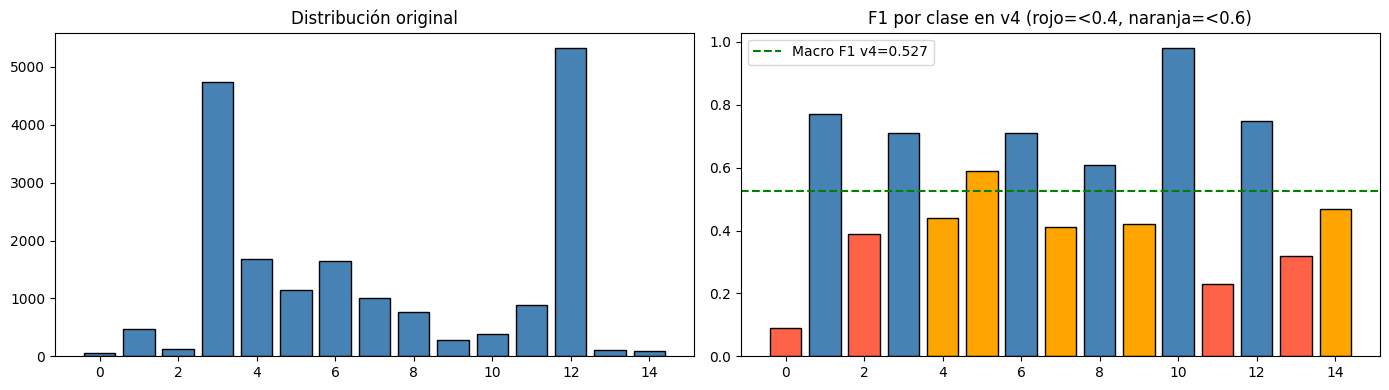

In [18]:
def compute_class_weights(labels, n_classes=15, manual_boost=None):
    """
    Pesos de clase con suavizado √ y boost manual selectivo.

    v7: eliminamos el boost×1.5 de clase 11.
    En v6 causó que clase 11 tuviera pred=476 con solo 178 reales en val,
    y pred=1108 (17.8% del test) siendo solo 4.7% del train.
    El modelo la sobrepredicía masivamente.

    Mantenemos boost solo para clase 0 (56 muestras, genuinamente subrepresentada).
    """
    counts = np.bincount(labels, minlength=n_classes).astype(float)
    counts = np.maximum(counts, 1.0)
    weights = np.sqrt(len(labels) / (n_classes * counts))
    weights = weights / weights.mean()

    if manual_boost:
        for cls, factor in manual_boost.items():
            weights[cls] *= factor
        weights = weights / weights.mean()

    return torch.FloatTensor(weights)


def get_sampler(labels, n_classes=15):
    counts = np.bincount(labels, minlength=n_classes).astype(float)
    counts = np.maximum(counts, 1.0)
    class_weights_s = 1.0 / np.sqrt(counts)
    max_count = counts.max()
    min_w = 1.0 / np.sqrt(max_count)
    class_weights_s = np.minimum(class_weights_s, min_w * 3.0)
    sample_weights = class_weights_s[labels]
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(labels),
        replacement=True
    )


is_aug = train_df['Id'].str.contains('_aug')
original_labels = train_df[~is_aug]['Target'].values

# Solo boost clase 0 (56 muestras). Clase 11 sin boost — en v6 causó pred=1108 en test
class_weights = compute_class_weights(
    original_labels, CFG['n_classes'],
    manual_boost={0: 1.5}
)

print('Pesos de clase:')
v6_f1 = {0:0.11, 1:0.85, 2:0.48, 3:0.76, 4:0.48, 5:0.65, 6:0.77,
          7:0.48, 8:0.64, 9:0.54, 10:0.98, 11:0.28, 12:0.80, 13:0.30, 14:0.47}
for i, w in enumerate(class_weights):
    count = (original_labels == i).sum()
    boost_note = ' ← BOOST×1.5' if i == 0 else (' ← sin boost (v6 sobrepredicía)' if i == 11 else '')
    print(f'  Clase {i:2d}: {count:5d} muestras | v6_F1={v6_f1[i]:.2f} | weight={w:.3f}{boost_note}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(15), np.bincount(original_labels, minlength=15), color='steelblue', edgecolor='black')
axes[0].set_title('Distribución original')
f1_vals = [v6_f1[i] for i in range(15)]
colors = ['tomato' if f < 0.4 else 'orange' if f < 0.6 else 'steelblue' for f in f1_vals]
axes[1].bar(range(15), f1_vals, color=colors, edgecolor='black')
axes[1].axhline(sum(f1_vals)/len(f1_vals), color='green', linestyle='--', label=f'Macro F1 v6≈0.57')
axes[1].set_title('F1 por clase en v6 (rojo=<0.4)')
axes[1].legend()
plt.tight_layout()
plt.show()


## 6. Modelo: AST (Audio Spectrogram Transformer)

### Arquitectura
```
Input: Mel-Spectrograma (1, 128, 863)
  ↓
Patch Embedding: divide en patches 16×16 → secuencia de tokens
  ↓
AST Encoder (12 capas Transformer, 768 dim, 12 heads)
  Pre-entrenado en AudioSet (2M clips, 527 clases de audio)
  ↓
CLS token → (batch, 768)
  ↓
Dropout(0.3) → Linear(768 → 15) → logits
```

### Por qué el CLS token es suficiente
En el Transformer, el CLS token agrega información global de TODOS los patches
via self-attention a lo largo de las 12 capas. No necesitamos LSTM adicional:
el propio mecanismo de atención captura dependencias temporales largas.

### Freeze strategy
- Épocas 1-3: solo entrenar el head Linear(768→15). El AST ya tiene features
  excelentes de AudioSet; entrenar primero el head estabiliza los gradientes.
- Épocas 4+: descongelar todo con LR muy diferencial (encoder lr × 0.01)

In [7]:
class ASTClassifier(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        import math
        n_mels   = cfg['n_mels']
        n_frames = int(math.ceil(cfg['duration'] * cfg['sample_rate'] / cfg['hop_length'])) + 1
        patch_size = 16
        stride     = 10

        freq_patches  = math.floor((n_mels   - patch_size) / stride) + 1  # 12
        time_patches  = math.floor((n_frames - patch_size) / stride) + 1  # 85
        total_patches = freq_patches * time_patches                        # 1020
        max_length    = total_patches + 2                                  # 1022

        print(f'Espectrograma: {n_mels}×{n_frames} → {freq_patches}×{time_patches} patches')
        print(f'Tokens totales esperados: {max_length}')

        print(f'Cargando {cfg["ast_model"]}...')
        self.ast = ASTModel.from_pretrained(
            cfg['ast_model'],
            ignore_mismatched_sizes=True,
        )

        # ── FIX: redimensionar el positional embedding manualmente ──
        # from_pretrained no siempre interpola correctamente en todas las versiones
        # de transformers. Lo hacemos nosotros con interpolación bilineal.
        old_pos_embed = self.ast.embeddings.position_embeddings  # (1, 1214, 768)
        old_len = old_pos_embed.shape[1]  # 1214

        if old_len != max_length:
            print(f'Interpolando positional embedding: {old_len} → {max_length}')
            # Reshape a (1, 768, 1214) para F.interpolate (espera canales en dim 1)
            pos = old_pos_embed.data.permute(0, 2, 1)          # (1, 768, 1214)
            pos = F.interpolate(pos, size=max_length, mode='linear', align_corners=False)
            pos = pos.permute(0, 2, 1)                          # (1, 1022, 768)
            self.ast.embeddings.position_embeddings = nn.Parameter(pos)
            print(f'Positional embedding actualizado: {self.ast.embeddings.position_embeddings.shape}')

        hidden_size = self.ast.config.hidden_size  # 768

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(cfg['dropout']),
            nn.Linear(hidden_size, cfg['n_classes'])
        )

        total = sum(p.numel() for p in self.parameters())
        print(f'AST listo. Hidden size: {hidden_size} | Total params: {total:,}')

    def freeze_encoder(self):
        for param in self.ast.parameters():
            param.requires_grad = False

    def unfreeze_encoder(self):
        for param in self.ast.parameters():
            param.requires_grad = True

    def forward(self, x):
        # x: (batch, 1, n_mels, T)
        x = x.squeeze(1)        # (batch, 128, 863)
        x = x.permute(0, 2, 1)  # (batch, 863, 128)

        outputs = self.ast(input_values=x)
        pooled  = outputs.pooler_output
        logits  = self.classifier(pooled)
        return logits


model = ASTClassifier(CFG).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Parámetros entrenables: {trainable:,} / {total:,}')

Espectrograma: 128×863 → 12×85 patches
Tokens totales esperados: 1022
Cargando MIT/ast-finetuned-audioset-10-10-0.4593...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Interpolando positional embedding: 1214 → 1022
Positional embedding actualizado: torch.Size([1, 1022, 768])
AST listo. Hidden size: 768 | Total params: 86,052,879
Parámetros entrenables: 86,052,879 / 86,052,879


## 7. Focal Loss

### ¿Por qué Focal Loss en vez de CrossEntropy?

CrossEntropy estándar trata todos los ejemplos por igual. Con desbalance 95:1, los ejemplos fáciles de clases mayoritarias dominan el gradiente.

Focal Loss añade un factor modulador $(1-p_t)^\gamma$:
- Si el modelo predice bien (p_t alto) → el factor es ~0 → contribución mínima
- Si el modelo falla (p_t bajo) → el factor es ~1 → contribución completa

Con γ=2: un ejemplo clasificado con 90% de confianza recibe 100x menos peso que uno con 10% de confianza. Esto fuerza al modelo a enfocarse en las muestras difíciles.

In [22]:
class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al., 2017) con class weights y label smoothing.
    
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    
    Params:
      gamma: factor de enfoque. 0=CrossEntropy, 2=buen balance (paper original)
      alpha: pesos de clase (tensor de 15 valores)
      label_smoothing: suaviza las etiquetas hard (0/1) → (ε/C, 1-ε+ε/C)
    """
    def __init__(self, gamma=2.0, alpha=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        if alpha is not None:
            self.register_buffer('alpha', alpha)
        else:
            self.alpha = None
    
    def forward(self, logits, targets):
        n_classes = logits.size(1)
        
        # Label smoothing
        if self.label_smoothing > 0:
            with torch.no_grad():
                smooth_targets = torch.zeros_like(logits)
                smooth_targets.fill_(self.label_smoothing / n_classes)
                smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing + self.label_smoothing / n_classes)
        else:
            smooth_targets = F.one_hot(targets, n_classes).float()
        
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)
        
        # Focal weight: (1 - p_t)^gamma
        focal_weight = (1.0 - probs) ** self.gamma
        
        # Loss por clase
        loss = -focal_weight * smooth_targets * log_probs
        
        # Class weights
        if self.alpha is not None:
            alpha_t = self.alpha.unsqueeze(0)  # (1, n_classes)
            loss = loss * alpha_t
        
        return loss.sum(dim=1).mean()


print('Focal Loss configurada con:')
print(f'  gamma = {CFG["focal_gamma"]} (factor de enfoque)')
print(f'  label_smoothing = {CFG["label_smoothing"]}')
print(f'  class_weights = tensor de {len(class_weights)} valores')

Focal Loss configurada con:
  gamma = 2.0 (factor de enfoque)
  label_smoothing = 0.1
  class_weights = tensor de 15 valores


## 8. Mixup: regularización por interpolación

Mixup (Zhang et al., 2018) crea muestras sintéticas interpolando pares:
- `x_mix = λ·x_i + (1-λ)·x_j`
- `y_mix = λ·y_i + (1-λ)·y_j`

Fuerza al modelo a aprender transiciones suaves entre clases → mejor generalización.

In [43]:
def mixup_data(x, y, alpha=0.3):
    """Mixup augmentation."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, logits, y_a, y_b, lam):
    """Loss para datos con mixup."""
    return lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)

## 9. Preparación de datos: Stratified K-Fold + DataLoaders

In [19]:
# =================================================================
# STRATIFIED K-FOLD
# =================================================================
# Decisión: el split se hace SOLO sobre las filas originales
# (sin las copias augmentadas). Las copias augmentadas de clases
# minoritarias siempre van a train, nunca a validación.

# Separar originales de augmentadas
is_augmented = train_df['Id'].str.contains('_aug')
train_original = train_df[~is_augmented].copy().reset_index(drop=True)
train_augmented = train_df[is_augmented].copy().reset_index(drop=True)

print(f'Originales: {len(train_original)} | Augmentadas: {len(train_augmented)}')

skf = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True, random_state=CFG['seed'])

train_original['fold'] = -1
for fold_idx, (_, val_idx) in enumerate(skf.split(train_original, train_original['Target'])):
    train_original.loc[val_idx, 'fold'] = fold_idx

# Seleccionar fold
fold = CFG['fold']
train_fold_orig = train_original[train_original['fold'] != fold].reset_index(drop=True)
val_fold_df = train_original[train_original['fold'] == fold].reset_index(drop=True)

# Agregar augmentadas al train (nunca al validation)
# Solo las augmentadas cuyos originales están en train_fold
train_orig_ids = set(train_fold_orig['Id'])
aug_for_fold = train_augmented[
    train_augmented['Id'].apply(lambda x: x.rsplit('_aug', 1)[0]).isin(train_orig_ids)
].reset_index(drop=True)

train_fold_df = pd.concat([train_fold_orig, aug_for_fold], ignore_index=True)

print(f'\nFold {fold}:')
print(f'  Train: {len(train_fold_df)} ({len(train_fold_orig)} orig + {len(aug_for_fold)} aug)')
print(f'  Val:   {len(val_fold_df)} (solo originales)')

# Datasets
train_dataset = MusicGenreDataset(train_fold_df, CFG, is_train=True)
val_dataset = MusicGenreDataset(val_fold_df, CFG, is_train=False)
test_dataset = MusicGenreDataset(test_df, CFG, is_train=False)

# WeightedRandomSampler
train_sampler = get_sampler(train_fold_df['Target'].values, CFG['n_classes'])

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG['batch_size'],
    sampler=train_sampler,
    num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory'],
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False,
    num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory']
)

print(f'\nTrain batches: {len(train_loader)} (con WeightedRandomSampler)')
print(f'Val batches:   {len(val_loader)}')

Originales: 18719 | Augmentadas: 3415

Fold 0:
  Train: 17710 (14975 orig + 2735 aug)
  Val:   3744 (solo originales)

Train batches: 1106 (con WeightedRandomSampler)
Val batches:   117


## 10. Optimizador — LR diferencial para AST

El AST tiene 86M parámetros pre-entrenados en AudioSet.
Usamos LR muy diferencial:
- **Fase 1** (épocas 1-3): solo el head Linear(768→15) con `lr=5e-4`
- **Fase 2** (épocas 4+): encoder `lr × 0.01 = 5e-6`, head `lr × 0.1 = 5e-5`

El encoder ya tiene features excelentes → necesita ajuste muy fino.
`weight_decay=1e-2` (mayor que v5) porque 86M params necesitan más L2.

In [23]:
def build_optimizer_and_scheduler(model, cfg, train_loader, encoder_frozen=True):
    """
    v7: encoder lr 5e-6→2e-5, div_factor 25→10.

    En v6 el encoder arrancaba con LR=2e-6 (5e-6/25) → casi no se movía.
    Ahora arranca con 2e-3 (1e-3/10) para la cabeza y 2e-6 para el encoder,
    sube rápidamente al máximo con pct_start=0.15.
    """
    head_params = list(model.classifier.parameters())

    if encoder_frozen:
        param_groups = [{'params': head_params, 'lr': cfg['lr']}]
        max_lrs = [cfg['lr']]
        n_epochs = cfg['freeze_epochs']
    else:
        encoder_params = [p for p in model.ast.parameters() if p.requires_grad]
        param_groups = [
            {'params': encoder_params, 'lr': cfg['lr'] * 0.02},  # 2e-5 (era 5e-6)
            {'params': head_params,    'lr': cfg['lr'] * 0.1},   # 1e-4
        ]
        max_lrs = [cfg['lr'] * 0.02, cfg['lr'] * 0.1]
        n_epochs = cfg['epochs'] - cfg['freeze_epochs']

    optimizer = AdamW(param_groups, weight_decay=cfg['weight_decay'])
    scheduler = OneCycleLR(
        optimizer,
        max_lr=max_lrs,
        epochs=n_epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.15,       # warmup más largo (10%→15%)
        anneal_strategy='cos',
        div_factor=10,        # LR inicial = max_lr/10 (era /25, muy bajo)
        final_div_factor=100  # LR final = max_lr/100 (era /1000)
    )
    return optimizer, scheduler


model.freeze_encoder()
optimizer, scheduler = build_optimizer_and_scheduler(
    model, CFG, train_loader, encoder_frozen=True
)
criterion = FocalLoss(
    gamma=CFG['focal_gamma'],
    alpha=class_weights.to(DEVICE),
    label_smoothing=CFG['label_smoothing']
)
scaler = GradScaler(enabled=CFG['fp16'])

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Fase 1: encoder CONGELADO ({CFG["freeze_epochs"]} épocas)')
print(f'Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')
print(f'Head LR: {CFG["lr"]} (div_factor=10 → arranca en {CFG["lr"]/10:.2e})')
print(f'Fase 2 (epoch {CFG["freeze_epochs"]+1}+):')
print(f'  Encoder LR max: {CFG["lr"]*0.02:.2e} (era 5e-6, ahora 2e-5)')
print(f'  Head LR max:    {CFG["lr"]*0.1:.2e}')


Fase 1: encoder CONGELADO (3 épocas)
Parámetros entrenables: 13,071 / 86,052,879 (0.0%)
Head LR: 0.0005
Fase 2 (epoch 4+): encoder lr=5.00e-06, head lr=5.00e-05


## 11. Funciones de entrenamiento y validación

In [9]:
def train_epoch(model, loader, optimizer, scheduler, criterion, scaler, device, cfg):
    """
    Entrenamiento con Mixup siempre activo y F1 honesto sobre todos los batches.
    """
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc='Training', leave=False)
    for inputs, labels in pbar:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Mixup siempre activo (p=1.0): más consistente como regularizador
        if cfg['use_mixup']:
            inputs, labels_a, labels_b, lam = mixup_data(inputs, labels, cfg['mixup_alpha'])

        optimizer.zero_grad()

        with autocast(enabled=cfg['fp16']):
            logits = model(inputs)
            if cfg['use_mixup']:
                loss = mixup_criterion(criterion, logits, labels_a, labels_b, lam)
            else:
                loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

        # F1 honesto: siempre acumular, usando etiqueta dominante en mixup
        with torch.no_grad():
            preds = logits.argmax(dim=1).cpu().numpy()
            if cfg['use_mixup']:
                true = labels_a.cpu().numpy() if lam >= 0.5 else labels_b.cpu().numpy()
            else:
                true = labels.cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(true)

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1


@torch.no_grad()
def val_epoch(model, loader, criterion, device, cfg):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    all_probs = []

    for inputs, labels in tqdm(loader, desc='Validation', leave=False):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(enabled=cfg['fp16']):
            logits = model(inputs)
            loss = criterion(logits, labels)

        total_loss += loss.item()
        probs = F.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_probs.append(probs)

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    all_probs = np.vstack(all_probs)
    return avg_loss, macro_f1, all_preds, all_labels, all_probs


print('Funciones de entrenamiento definidas.')


Funciones de entrenamiento definidas.


## 12. Entrenamiento principal con Early Stopping

In [ ]:
best_f1 = 0.0
best_epoch = 0
patience = 8  # Reducido: AST da señal rápida
patience_counter = 0
encoder_unfrozen = False

history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': [], 'lr': []}
save_path = f'best_model_fold{fold}.pth'

print('=' * 70)
print(f'Entrenamiento v6 — AST (AudioSet pre-training) — Fold {fold}')
print(f'Épocas 1-{CFG["freeze_epochs"]}: encoder CONGELADO (solo head)')
print(f'Audio: {CFG["duration"]}s | Batch: {CFG["batch_size"]} | ~{int(len(train_loader))} batches/epoch')
print(f'Épocas {CFG["freeze_epochs"]+1}+: encoder lr×0.01, head lr×0.1')
print(f'Batch: {CFG["batch_size"]} | Epochs: {CFG["epochs"]} | Patience: {patience}')
print('=' * 70)

for epoch in range(1, CFG['epochs'] + 1):

    # Descongelar encoder después de freeze_epochs
    if epoch == CFG['freeze_epochs'] + 1 and not encoder_unfrozen:
        print(f'\n>>> Epoch {epoch}: DESCONGELANDO encoder AST <<<')
        model.unfreeze_encoder()
        optimizer, scheduler = build_optimizer_and_scheduler(
            model, CFG, train_loader, encoder_frozen=False
        )
        encoder_unfrozen = True
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'    Parámetros entrenables: {trainable:,}')
        print(f'    Encoder LR: {CFG["lr"]*0.01:.2e} | Head LR: {CFG["lr"]*0.1:.2e}\n')

    current_lr = optimizer.param_groups[-1]['lr']

    train_loss, train_f1 = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, scaler, DEVICE, CFG
    )
    val_loss, val_f1, val_preds, val_labels, val_probs = val_epoch(
        model, val_loader, criterion, DEVICE, CFG
    )

    history['train_loss'].append(train_loss)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)

    improved = val_f1 > best_f1
    if improved:
        best_f1 = val_f1
        best_epoch = epoch
        patience_counter = 0
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'best_f1': best_f1, 'cfg': CFG}, save_path)
    else:
        patience_counter += 1

    phase = 'FROZEN' if epoch <= CFG['freeze_epochs'] else 'FINETUNE'
    status = '✓ BEST' if improved else f'(patience {patience_counter}/{patience})'
    gap = train_f1 - val_f1
    print(
        f'[{phase}] Epoch {epoch:2d}/{CFG["epochs"]} | '
        f'Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f} | '
        f'Gap: {gap:+.4f} | LR: {current_lr:.2e} | {status}'
    )

    if encoder_unfrozen and patience_counter >= patience:
        print(f'\nEarly stopping epoch {epoch}. Mejor F1: {best_f1:.4f} (epoch {best_epoch})')
        break

print(f'\nMejor Macro F1 en val: {best_f1:.4f} (epoch {best_epoch})')


Entrenamiento v6 — AST (AudioSet pre-training) — Fold 0
Épocas 1-3: encoder CONGELADO (solo head)
Épocas 4+: encoder lr×0.01, head lr×0.1
Batch: 16 | Epochs: 40 | Patience: 12


Training:   0%|          | 0/1106 [00:00<?, ?it/s]

Validation:   0%|          | 0/117 [00:00<?, ?it/s]

[FROZEN] Epoch  1/40 | Train F1: 0.3023 | Val F1: 0.3974 | Gap: -0.0951 | LR: 2.00e-05 | ✓ BEST


Training:   0%|          | 0/1106 [00:00<?, ?it/s]

...

[FINETUNE] Epoch  6/40 | Train F1: 0.5464 | Val F1: 0.4912 | Gap: +0.0552 | LR: 2.91e-05 | ✓ BEST


Training:   0%|          | 0/1106 [00:00<?, ?it/s]

Validation:   0%|          | 0/117 [00:00<?, ?it/s]

[FINETUNE] Epoch  7/40 | Train F1: 0.6128 | Val F1: 0.4947 | Gap: +0.1181 | LR: 4.59e-05 | ✓ BEST


Training:   0%|          | 0/1106 [00:00<?, ?it/s]

## 13. Visualización de resultados de entrenamiento

In [1]:
# =================================================================
# CURVAS DE ENTRENAMIENTO
# =================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train', color='steelblue')
axes[0].plot(history['val_loss'], label='Val', color='coral')
axes[0].axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# F1
axes[1].plot(history['train_f1'], label='Train', color='steelblue')
axes[1].plot(history['val_f1'], label='Val', color='coral')
axes[1].axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
axes[1].set_title('Macro F1-Score')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# LR
axes[2].plot(history['lr'], color='purple')
axes[2].set_title('Learning Rate (Head)')
axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log')

plt.suptitle(f'Entrenamiento — Fold {fold} | Best Val F1: {best_f1:.4f}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

## 14. Evaluación detallada del mejor modelo

Mejor modelo cargado (epoch 10, F1=0.5722)


Validation:   0%|          | 0/117 [00:00<?, ?it/s]


Macro F1-Score en validación: 0.5722

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.07      0.27      0.11        11
           1       0.80      0.90      0.85        93
           2       0.39      0.63      0.48        27
           3       0.83      0.70      0.76       947
           4       0.61      0.40      0.48       338
           5       0.66      0.64      0.65       228
           6       0.75      0.79      0.77       329
           7       0.44      0.53      0.48       202
           8       0.69      0.60      0.64       153
           9       0.48      0.61      0.54        57
          10       0.99      0.97      0.98        76
          11       0.19      0.51      0.28       178
          12       0.89      0.72      0.80      1064
          13       0.24      0.39      0.30        23
          14       0.33      0.83      0.47        18

    accuracy                           0.67      3744
   macro avg   

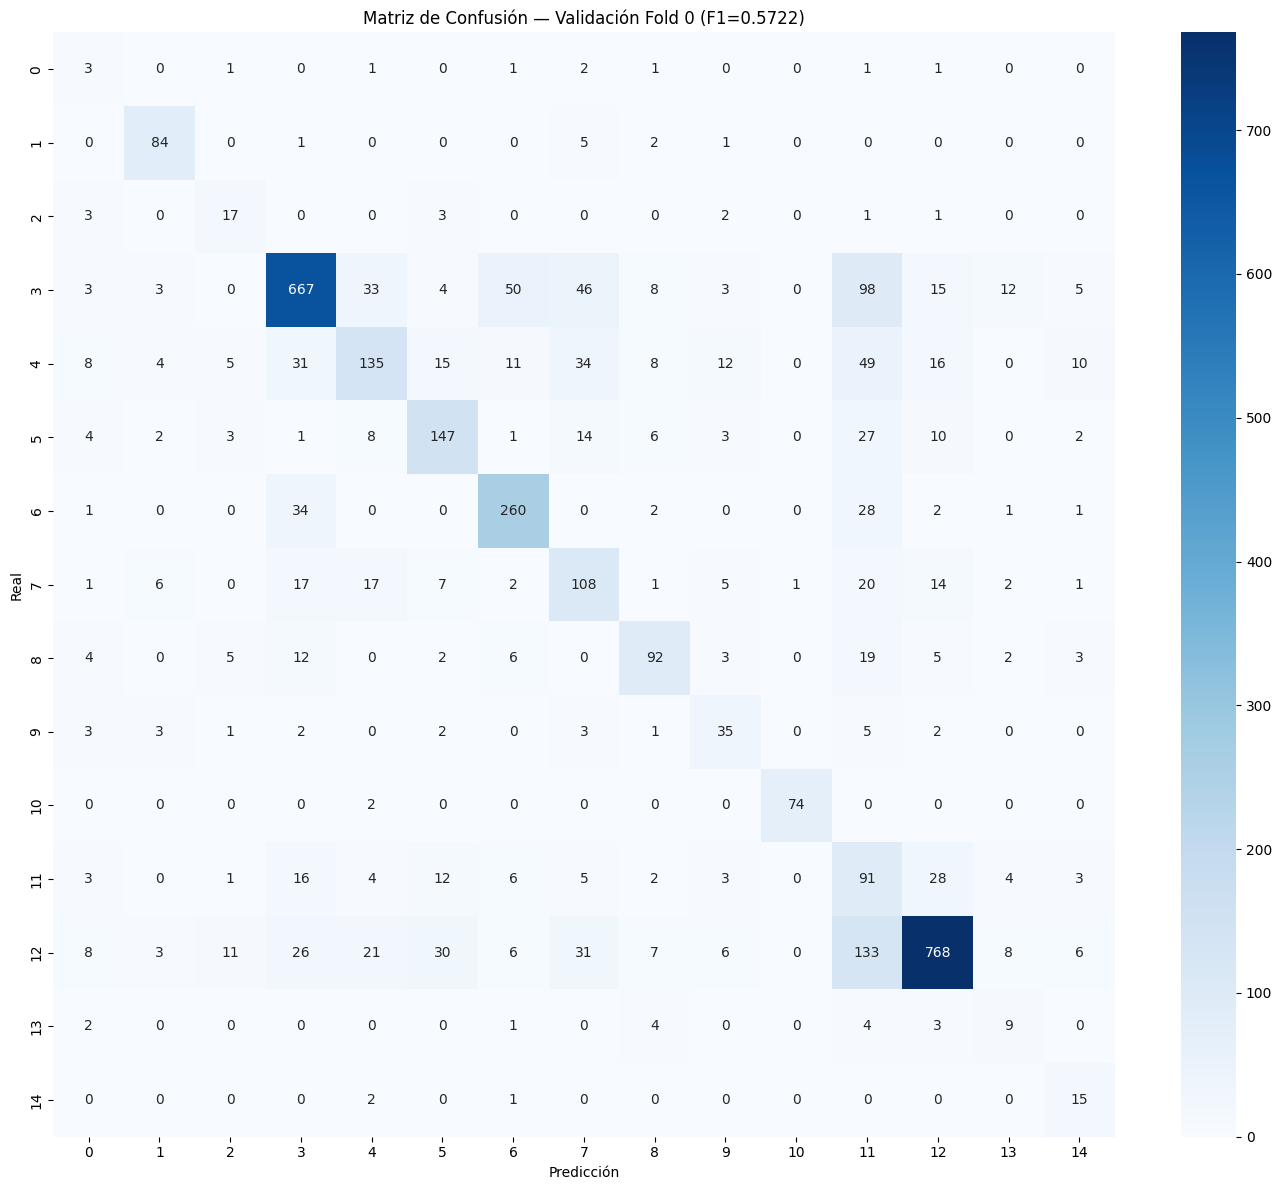

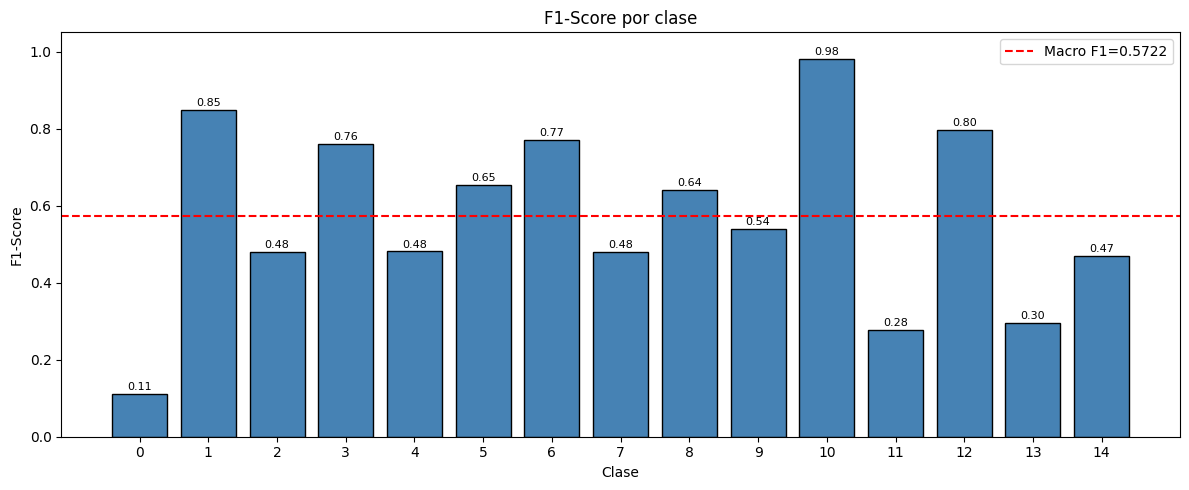

In [24]:
# Cargar mejor modelo
save_path = 'best_model_fold0.pth'
checkpoint = torch.load(save_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Mejor modelo cargado (epoch {checkpoint["epoch"]}, F1={checkpoint["best_f1"]:.4f})')

# Evaluación final
_, final_f1, final_preds, final_labels, _ = val_epoch(
    model, val_loader, criterion, DEVICE, CFG
)

print(f'\nMacro F1-Score en validación: {final_f1:.4f}')
print('\nReporte de clasificación:')
print(classification_report(final_labels, final_preds, zero_division=0))

# Diagnóstico: distribución de predicciones vs real
print('\nDistribución predicciones vs real:')
pred_counts = Counter(final_preds)
for cls in range(15):
    real = (np.array(final_labels) == cls).sum()
    pred = pred_counts.get(cls, 0)
    print(f'  Clase {cls:2d}: real={real:4d} | pred={pred:4d}')

# Matriz de confusión
cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(15), yticklabels=range(15))
plt.title(f'Matriz de Confusión — Validación Fold {fold} (F1={final_f1:.4f})')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# F1 por clase
f1_per_class = f1_score(final_labels, final_preds, average=None, zero_division=0)
plt.figure(figsize=(12, 5))
bars = plt.bar(range(15), f1_per_class, color='steelblue', edgecolor='black')
plt.axhline(final_f1, color='red', linestyle='--', label=f'Macro F1={final_f1:.4f}')
plt.xlabel('Clase')
plt.ylabel('F1-Score')
plt.title('F1-Score por clase')
plt.xticks(range(15))
plt.ylim(0, 1.05)
plt.legend()
for bar, f1_val in zip(bars, f1_per_class):
    plt.text(bar.get_x() + bar.get_width()/2, f1_val + 0.01, f'{f1_val:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 15. Predicción con Test Time Augmentation (TTA)

TTA promedia las probabilidades de múltiples pasadas con diferentes augmentaciones.
Reduce la varianza y típicamente mejora el F1 en 1-3 puntos.

In [25]:
@torch.no_grad()
def predict_with_tta(model, dataset, device, cfg, n_tta=5):
    """
    TTA corregido: NUNCA usa SpecAugment en las pasadas de test.

    En v4, el TTA con SpecAugment bajó el score 0.025 en Kaggle:
      val local (sin TTA): 0.5270
      Kaggle (con TTA):    0.5025 → −0.025

    El SpecAugment enmascara partes del espectrograma aleatoriamente.
    En train esto fuerza robustez, pero en test destruye información
    que el modelo necesita para clasificar correctamente.

    Solución: TTA con flip temporal (invertir el eje del tiempo) que
    sí es una augmentación válida para audio en inferencia.
    """
    model.eval()
    dataset.is_train = False  # SIEMPRE sin SpecAugment en TTA

    all_probs = []

    for tta_idx in range(n_tta):
        loader = DataLoader(
            dataset,
            batch_size=cfg['batch_size'] * 2,
            shuffle=False,
            num_workers=cfg['num_workers'],
            pin_memory=cfg['pin_memory']
        )

        tta_probs = []
        for batch in tqdm(loader, desc=f'TTA {tta_idx+1}/{n_tta}', leave=False):
            if isinstance(batch, (list, tuple)):
                inputs = batch[0].to(device, non_blocking=True)
            else:
                inputs = batch.to(device, non_blocking=True)

            # Pasada 0: original
            # Pasadas 1+: flip temporal (invertir eje del tiempo del espectrograma)
            # Esto es válido en audio: la misma canción al revés sigue siendo del mismo género
            if tta_idx > 0:
                inputs = torch.flip(inputs, dims=[-1])  # Flip en eje temporal

            with autocast(enabled=cfg['fp16']):
                logits = model(inputs)
            probs = F.softmax(logits, dim=1).cpu().numpy()
            tta_probs.append(probs)

        all_probs.append(np.vstack(tta_probs))

    mean_probs = np.mean(all_probs, axis=0)
    predictions = np.argmax(mean_probs, axis=1)
    return predictions, mean_probs


print('Generando predicciones con TTA (flip temporal, sin SpecAugment)...')
test_preds, test_probs = predict_with_tta(model, test_dataset, DEVICE, CFG, n_tta=3)

print(f'\nPredicciones: {len(test_preds)}')
print('Distribución:')
pred_dist = Counter(test_preds)
for cls in sorted(pred_dist.keys()):
    print(f'  Clase {cls:2d}: {pred_dist[cls]:5d}')


Generando predicciones con TTA (flip temporal, sin SpecAugment)...


TTA 1/3:   0%|          | 0/195 [00:00<?, ?it/s]

TTA 2/3:   0%|          | 0/195 [00:00<?, ?it/s]

TTA 3/3:   0%|          | 0/195 [00:00<?, ?it/s]


Predicciones: 6240
Distribución:
  Clase  0:   137
  Clase  1:   112
  Clase  2:    49
  Clase  3:  1385
  Clase  4:   643
  Clase  5:   229
  Clase  6:   722
  Clase  7:   430
  Clase  8:   116
  Clase  9:    69
  Clase 10:   126
  Clase 11:  1108
  Clase 12:  1010
  Clase 13:    12
  Clase 14:    92


## 16. Generar archivo de submission

In [26]:
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'Target': test_preds
})

submission.to_csv('submission.csv', index=False)

print(f'Submission generada: {len(submission)} filas')
print(submission.head(10))

# Verificaciones
assert len(submission) == len(test_df), 'ERROR: número de predicciones no coincide'
assert submission['Target'].between(0, 14).all(), 'ERROR: predicciones fuera de [0, 14]'
assert not submission.isnull().any().any(), 'ERROR: valores nulos'
print('\n✓ Formato verificado correctamente')

Submission generada: 6240 filas
                 Id  Target
0  000ad3f474c22732       3
1  000c01fb027c9720      12
2  0011f18cdfde1eb2      11
3  002c8a7c75197a78      11
4  0034afa0ffefe542      11
5  00360bf471794cde      11
6  003fd6961434c5a8      11
7  0045bb6d5fdfe02c       3
8  004e91ea1bc30ed6       2
9  0050ea62569bbbe5       3

✓ Formato verificado correctamente


# Submit Kaggle

In [27]:
!kaggle competitions submit -c music-genres-2026-i -f submission.csv  -m "Version 4"

100%|█████████████████████████████████████████| 118k/118k [00:00<00:00, 286kB/s]
Successfully submitted to Music genres

In [ ]:
from IPython.display import FileLink

# Escribe el nombre exacto de tu archivo
FileLink('submission.csv')

## 17. (Opcional) Ensemble de múltiples folds

Para máximo rendimiento, entrena los 5 folds y promedia sus predicciones.
El ensemble reduce la varianza y típicamente mejora el F1 en 2-4 puntos.

In [ ]:
USE_ENSEMBLE = False  # Cambiar a True después de entrenar todos los folds

if USE_ENSEMBLE:
    all_fold_probs = []
    
    for fold_idx in range(CFG['n_folds']):
        fold_path = f'best_model_fold{fold_idx}.pth'
        if not os.path.exists(fold_path):
            print(f'Fold {fold_idx} no encontrado, saltando...')
            continue
        
        print(f'Cargando fold {fold_idx}...')
        fold_model = AudioClassifier(CFG).to(DEVICE)
        ckpt = torch.load(fold_path, map_location=DEVICE)
        fold_model.load_state_dict(ckpt['model_state_dict'])
        
        _, probs = predict_with_tta(fold_model, test_dataset, DEVICE, CFG, n_tta=3)
        all_fold_probs.append(probs)
        print(f'  F1 validación: {ckpt["best_f1"]:.4f}')
        del fold_model
        torch.cuda.empty_cache()
    
    if all_fold_probs:
        ensemble_probs = np.mean(all_fold_probs, axis=0)
        ensemble_preds = np.argmax(ensemble_probs, axis=1)
        
        ensemble_sub = pd.DataFrame({'Id': test_df['Id'], 'Target': ensemble_preds})
        ensemble_sub.to_csv('submission_ensemble.csv', index=False)
        print(f'\nEnsemble de {len(all_fold_probs)} folds → submission_ensemble.csv')
else:
    print('Ensemble desactivado. Usa submission.csv del fold único.')
    print('Para ensemble: entrena todos los folds cambiando CFG["fold"] = 0,1,2,3,4')

## Resumen de decisiones — v6

| Componente | v5 (CNN+BiLSTM) | v6 (AST) | Justificación |
|---|---|---|---|
| **Backbone** | EfficientNet-B0 (ImageNet) | **AST (AudioSet)** | Pre-entrenamiento en audio directo |
| **Temporal** | BiLSTM 1 capa | **Transformer 12 capas** | Atención global, no secuencial |
| **Input** | 3 canales (RGB simulado) | **1 canal** | AST diseñado para espectrogramas |
| **Normalización** | z-score local | **AudioSet (µ=-4.27, σ=4.57)** | Igual al pre-entrenamiento |
| **Params** | 6.5M | **86M** (ViT-Base) |
| **LR encoder** | 3e-5 | **5e-6** (×0.01) | Encoder ya pre-entrenado en audio |
| **Weight decay** | 1e-3 | **1e-2** | Más L2 para 86M params |
| **TTA** | Flip temporal | Flip temporal | Sin SpecAugment (perjudica) |
| **Todo lo demás** | — | Mantenido | Caché, Focal Loss, sampler, augmentation |
